# Level 1 — Skip-Connection Ablation Study

**Companion to `colab_level1.ipynb`.** The base notebook trains the final residual model; this notebook *plays with the architecture* to demonstrate the four points the task asks us to discuss:

1. **Why residual connections help optimization** — residual vs plain at matched depth.
2. **How skip connections improve gradient flow** — per-block gradient norms.
3. **The effect of network depth on performance** — a depth sweep (2 / 6 / 12 blocks).
4. **Challenges** — dimension mismatch, stability of the deep plain net.

The idea (from He et al. 2015): take the *exact same* convolutional stack and toggle a single `use_skip` flag. With skips it is a ResNet; without, it is a **plain** network of identical depth. Everything is still built from scratch — we only add a flag, importing no pre-built ResNet.

Runs top-to-bottom on Colab (GPU). Set `EPOCHS` lower for a quick smoke test.

In [1]:
import os, time, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
assert DEVICE.type != 'cpu', 'Enable a GPU runtime (Runtime > Change runtime type > GPU) before running the ablation.'

DATA_DIR    = os.path.expanduser(os.environ.get('DATA_DIR', '/content/datasets'))
OUT_DIR     = os.path.abspath(os.environ.get('OUT_DIR', '/content/outputs'))
WEIGHTS_DIR = os.path.abspath(os.environ.get('WEIGHTS_DIR', '/content/model_weights'))
for d in (DATA_DIR, OUT_DIR, WEIGHTS_DIR): os.makedirs(d, exist_ok=True)
print('device:', DEVICE, '| out dir:', OUT_DIR)

device: cuda | out dir: /content/outputs


## 1. Data — CIFAR-10
Same augmentation as the base notebook: random crop + horizontal flip for train, normalization for both.

In [2]:
import os, time, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Prefer CUDA (NVIDIA), then MPS (Apple Silicon GPU), then CPU.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
DATA_DIR = os.path.expanduser(os.environ.get("DATA_DIR", "/content/datasets"))
OUT_DIR = os.path.abspath(os.environ.get("OUT_DIR", "/content/outputs"))
WEIGHTS_DIR = os.path.abspath(os.environ.get("WEIGHTS_DIR", "/content/model_weights"))
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(WEIGHTS_DIR, exist_ok=True)
print("device:", DEVICE, "| data dir:", DATA_DIR)

device: cuda | data dir: /content/datasets


In [3]:
import torchvision
import torchvision.transforms as T
import pickle
from PIL import Image
import numpy as np
import torch
import os

# Re-defining DATA_DIR and DEVICE for robustness
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
DATA_DIR = os.path.expanduser(os.environ.get("DATA_DIR", "/content/"))

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_tf = T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])

# Custom CIFAR-10 Dataset Loader
class CIFAR10Custom(torch.utils.data.Dataset):
    base_folder = ""
    # Default lists for all batches if not specified
    _all_train_list = [
        "data_batch_1",
        "data_batch_2",
        "data_batch_3",
        "data_batch_4",
        "data_batch_5",
    ]
    _all_test_list = ["test_batch"]

    meta = {
        "filename": "batches.meta",
        "key": "label_names",
        "md5": "5ff9c542aee3564f39fa8dee972fc0bb", # This MD5 is from torchvision, not strictly needed for custom loading
    }

    def __init__(self, root, train=True, transform=None, load_batches=None):
        self.root = os.path.expanduser(root)
        self.transform = transform
        self.train = train  # training set or test set

        if self.train:
            if load_batches is None:
                downloaded_list = self._all_train_list
            else:
                downloaded_list = load_batches
        else:
            if load_batches is None:
                downloaded_list = self._all_test_list
            else:
                downloaded_list = load_batches # Allow specifying test batches too

        self.data = []
        self.targets = []

        # Load the pickled data
        for file_name in downloaded_list:
            file_path = os.path.join(self.root, file_name)
            with open(file_path, "rb") as f:
                entry = pickle.load(f, encoding="latin1")
                self.data.append(entry["data"])
                self.targets.extend(entry["labels"])

        self.data = np.vstack(self.data).reshape(-1, 3, 32, 32)
        self.data = self.data.transpose((0, 2, 3, 1))  # convert to HWC (Height, Width, Channel) for PIL Image

        self._load_meta()

    def _load_meta(self):
        path = os.path.join(self.root, self.meta["filename"])
        with open(path, "rb") as infile:
            data = pickle.load(infile, encoding="latin1")
            self.classes = data[self.meta["key"]]
        self.class_to_idx = {_class: i for i, _class in enumerate(self.classes)}


    def __getitem__(self, index):
        img, target = self.data[index], self.targets[index]
        img = Image.fromarray(img) # Convert numpy array to PIL Image for torchvision.transforms compatibility

        if self.transform is not None:
            img = self.transform(img)

        return img, target

    def __len__(self):
        return len(self.data)

train_set = CIFAR10Custom(DATA_DIR, train=True,  transform=train_tf, load_batches=["data_batch_2" ,"data_batch_1","data_batch_3","data_batch_4","data_batch_5"]) # Load only data_batch_1
test_set  = CIFAR10Custom(DATA_DIR, train=False, transform=test_tf) # Test set loads its default
CLASSES = train_set.classes

BATCH = 1024
_pin = (DEVICE.type == "cuda")
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=_pin)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=1024,  shuffle=False, num_workers=0, pin_memory=_pin)
print("train:", len(train_set), "test:", len(test_set), "classes:", CLASSES)

train: 50000 test: 10000 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. The model — `ResidualBlock` and `CustomResNet` with a `use_skip` flag

The **only** change from the base notebook is the `use_skip` argument. When `use_skip=False` the forward pass drops the `+ shortcut(x)` term, turning the identical conv stack into a plain network. Note the plain net still downsamples correctly (via `conv1`'s stride), so both variants have the same feature-map shapes at every stage — the comparison is clean.

In [4]:
class ResidualBlock(nn.Module):
    '''Custom residual block. use_skip=False makes it a plain (non-residual) block.'''
    def __init__(self, in_ch, out_ch, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        if use_skip:
            if stride != 1 or in_ch != out_ch:          # dimension mismatch -> 1x1 projection
                self.shortcut = nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                    nn.BatchNorm2d(out_ch))
            else:
                self.shortcut = nn.Identity()           # shapes match -> parameter-free identity
        else:
            self.shortcut = None                         # plain block: no skip at all

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:
            out = out + self.shortcut(x)                 # <-- the residual add
        return F.relu(out)


class CustomResNet(nn.Module):
    def __init__(self, num_classes=10, blocks_per_stage=(2,2,2), widths=(64,128,256), use_skip=True):
        super().__init__()
        assert 2 <= len(widths) <= 4, '2-4 residual stages'
        assert all(1 <= b <= 3 for b in blocks_per_stage), '1-3 blocks per stage'
        assert all(widths[i] < widths[i+1] for i in range(len(widths)-1)), 'increasing channel depth'
        self.use_skip = use_skip
        self.stem = nn.Sequential(
            nn.Conv2d(3, widths[0], 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(widths[0]), nn.ReLU(inplace=True))
        stages, in_ch = [], widths[0]
        for si, (w, nb) in enumerate(zip(widths, blocks_per_stage)):
            for bi in range(nb):
                stride = 2 if (bi == 0 and si > 0) else 1
                stages.append(ResidualBlock(in_ch, w, stride=stride, use_skip=use_skip))
                in_ch = w
        self.stages = nn.Sequential(*stages)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(in_ch, num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x); x = self.stages(x)
        return self.fc(self.gap(x).flatten(1))

## 3. Training utilities
One `train_model` that builds a variant, trains it with the same recipe (SGD + cosine LR, cross-entropy), and returns its history. Plain cross-entropy (no label smoothing) so the loss curves reflect raw optimization behaviour.

In [5]:
def evaluate(model, loader):
    model.eval(); loss_sum = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x); loss = F.cross_entropy(out, y)
            loss_sum += loss.item()*x.size(0)
            correct  += (out.argmax(1)==y).sum().item(); total += x.size(0)
    return loss_sum/total, correct/total

def train_model(blocks_per_stage, widths, use_skip, epochs, lr=0.1, verbose=True):
    torch.manual_seed(SEED)  # identical init/order across skip on/off for a fair comparison
    model = CustomResNet(blocks_per_stage=blocks_per_stage, widths=widths, use_skip=use_skip).to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4, nesterov=True)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {k: [] for k in ('train_loss','train_acc','val_loss','val_acc')}
    for ep in range(epochs):
        model.train(); t0 = time.time(); rl = correct = total = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); out = model(x); loss = F.cross_entropy(out, y)
            loss.backward(); opt.step()
            rl += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); total += x.size(0)
        sched.step()
        vl, va = evaluate(model, test_loader)
        hist['train_loss'].append(rl/total); hist['train_acc'].append(correct/total)
        hist['val_loss'].append(vl);        hist['val_acc'].append(va)
        if verbose:
            print(f'  ep {ep+1:02d}/{epochs} | train acc {correct/total:.3f} | val acc {va:.3f} | {time.time()-t0:.1f}s', flush=True)
    return model, hist

def block_grad_norms(model, n_batches=20):
    '''Mean L2 norm of conv1-weight gradients per block, averaged over a few train batches.'''
    model.train()
    acc = np.zeros(len(model.stages)); seen = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        model.zero_grad(); F.cross_entropy(model(x), y).backward()
        acc += np.array([b.conv1.weight.grad.norm().item() for b in model.stages]); seen += 1
        if seen >= n_batches: break
    return acc/seen

## 4. Run the sweep — depth x skip on/off

Three depths, all within the task constraints (2-4 stages, 1-3 blocks/stage, increasing width), each trained twice (residual vs plain): **6 runs**. Optionally logs each to MLflow.

| Tag | Stages x blocks | Widths | Residual blocks |
|---|---|---|---|
| shallow | (1, 1) | 64, 128 | 2 |
| medium  | (2, 2, 2) | 64, 128, 256 | 6 |
| deep    | (3, 3, 3, 3) | 64, 128, 256, 512 | 12 |

In [6]:
!pip install -q mlflow

In [7]:
import os
from sklearn.metrics import classification_report, confusion_matrix

EPOCHS = 5                   # 5 shows the story
USE_MLFLOW = True             # log every variant + its artifacts to the tracking server
MLFLOW_URI = 'https://busily-scalping-devotee.ngrok-free.dev'

CONFIGS = [
    ('shallow', (1,1),       (64,128)),
    ('medium',  (2,2,2),     (64,128,256)),
    ('deep',    (3,3,3,3),   (64,128,256,512)),
]

if USE_MLFLOW:
    import mlflow
    mlflow.set_tracking_uri(MLFLOW_URI); mlflow.set_experiment('cifar10-skip-ablation')

def make_eval_artifacts(name, model, hist):
    """Save training/val curves, classification report, confusion matrix. Returns (final_acc, [paths])."""
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].plot(hist['train_loss'], label='train'); ax[0].plot(hist['val_loss'], label='val')
    ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist['train_acc'], label='train'); ax[1].plot(hist['val_acc'], label='val')
    ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.suptitle(f'Training & validation curves - {name}')
    curves_path = os.path.join(OUT_DIR, f'{name}_training_curves.png')
    plt.tight_layout(); plt.savefig(curves_path, dpi=120); plt.close(fig)

    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(DEVICE)); ps.append(out.argmax(1).cpu().numpy()); ys.append(y.numpy())
    y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
    final_acc = float((y_true == y_pred).mean())

    report = classification_report(y_true, y_pred, target_names=CLASSES, digits=3)
    report_path = os.path.join(OUT_DIR, f'{name}_classification_report.txt')
    with open(report_path, 'w') as f: f.write(f'final_test_accuracy: {final_acc:.4f}\n\n' + report)

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7,6)); im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, rotation=45, ha='right'); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(f'Confusion matrix - {name}')
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=7)
    plt.colorbar(im); cm_path = os.path.join(OUT_DIR, f'{name}_confusion_matrix.png')
    plt.tight_layout(); plt.savefig(cm_path, dpi=120); plt.close(fig)
    return final_acc, [curves_path, report_path, cm_path]

results, models = {}, {}          # models kept in memory for the gradient-flow probe
for tag, bps, widths in CONFIGS:
    for use_skip in (True, False):
        name = f"{tag}_{'res' if use_skip else 'plain'}"
        print(f'=== {name}  ({sum(bps)} blocks) ===', flush=True)
        INIT_LR = 0.1
        model, hist = train_model(bps, widths, use_skip, EPOCHS, lr=INIT_LR)
        nparams = sum(p.numel() for p in model.parameters())

        ckpt_path = os.path.join(WEIGHTS_DIR, f'{name}.pt')
        torch.save({'state_dict': model.state_dict(), 'blocks_per_stage': bps,
                    'widths': widths, 'use_skip': use_skip}, ckpt_path)

        final_acc, art_paths = make_eval_artifacts(name, model, hist)
        results[name] = {'hist': hist, 'params': nparams, 'blocks': sum(bps),
                         'tag': tag, 'use_skip': use_skip,
                         'best_val': max(hist['val_acc']), 'final_val': hist['val_acc'][-1],
                         'final_test_acc': final_acc}
        models[name] = model
        print(f'  -> best val {max(hist["val_acc"]):.4f} | final test {final_acc:.4f}', flush=True)

        if USE_MLFLOW:
            with mlflow.start_run(run_name=name):
                mlflow.log_params({'tag': tag, 'use_skip': use_skip, 'blocks': sum(bps),
                                   'blocks_per_stage': str(bps), 'widths': str(widths),
                                   'params': nparams, 'epochs': EPOCHS, 'init_lr': INIT_LR,
                                   'optimizer': 'SGD', 'weight_decay': 5e-4})
                for e in range(len(hist['val_acc'])):
                    for k in ('train_loss','train_acc','val_loss','val_acc'):
                        mlflow.log_metric(k, float(hist[k][e]), step=e+1)
                mlflow.log_metric('best_val_acc', float(max(hist['val_acc'])))
                mlflow.log_metric('final_test_acc', final_acc)
                for p in [ckpt_path] + art_paths:
                    mlflow.log_artifact(p)      # weights + curves + report + confusion matrix
        print(flush=True)

=== shallow_res  (2 blocks) ===
  ep 01/5 | train acc 0.311 | val acc 0.320 | 5.8s
  ep 02/5 | train acc 0.432 | val acc 0.455 | 5.5s
  ep 03/5 | train acc 0.509 | val acc 0.480 | 5.5s
  ep 04/5 | train acc 0.561 | val acc 0.537 | 5.5s
  ep 05/5 | train acc 0.592 | val acc 0.580 | 5.7s
  -> best val 0.5798 | final test 0.5798
🏃 View run shallow_res at: https://busily-scalping-devotee.ngrok-free.dev/#/experiments/4/runs/a5e6bb7b6eb74ad98413ce3e3ee5ef04
🧪 View experiment at: https://busily-scalping-devotee.ngrok-free.dev/#/experiments/4

=== shallow_plain  (2 blocks) ===
  ep 01/5 | train acc 0.303 | val acc 0.337 | 5.3s
  ep 02/5 | train acc 0.429 | val acc 0.388 | 5.3s
  ep 03/5 | train acc 0.509 | val acc 0.435 | 5.3s
  ep 04/5 | train acc 0.571 | val acc 0.564 | 5.5s
  ep 05/5 | train acc 0.601 | val acc 0.593 | 5.3s
  -> best val 0.5929 | final test 0.5929
🏃 View run shallow_plain at: https://busily-scalping-devotee.ngrok-free.dev/#/experiments/4/runs/1a5bc01dc3ee4657b1ecab349eddd7a

## 5. Result 1 — residual vs plain, and the effect of depth

evaluating: medium_res


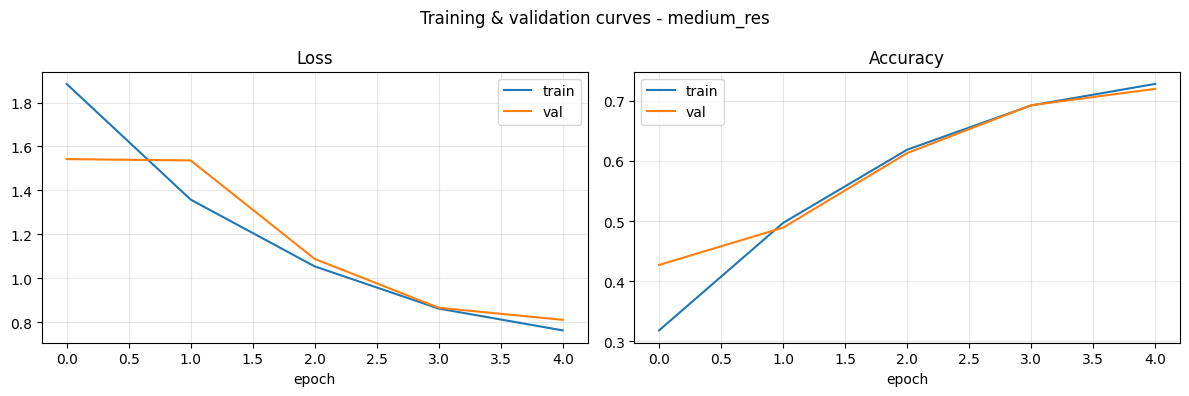

best val acc: 0.7199


In [8]:
# pick the model to evaluate (default: best residual variant by val accuracy)
EVAL_NAME = max((k for k in results if results[k]['use_skip']), key=lambda k: results[k]['best_val'])
print('evaluating:', EVAL_NAME)

# --- training & validation curves ---
h = results[EVAL_NAME]['hist']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['train_loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h['train_acc'], label='train'); ax[1].plot(h['val_acc'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.suptitle(f'Training & validation curves - {EVAL_NAME}')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, f'{EVAL_NAME}_training_curves.png'), dpi=120); plt.show()
print(f"best val acc: {max(h['val_acc']):.4f}")

FINAL TEST ACCURACY (medium_res): 0.7199

              precision    recall  f1-score   support

    airplane      0.788     0.689     0.735      1000
  automobile      0.872     0.849     0.860      1000
        bird      0.705     0.458     0.555      1000
         cat      0.518     0.587     0.550      1000
        deer      0.639     0.638     0.638      1000
         dog      0.592     0.680     0.633      1000
        frog      0.687     0.824     0.749      1000
       horse      0.839     0.713     0.771      1000
        ship      0.835     0.873     0.853      1000
       truck      0.789     0.888     0.835      1000

    accuracy                          0.720     10000
   macro avg      0.726     0.720     0.718     10000
weighted avg      0.726     0.720     0.718     10000



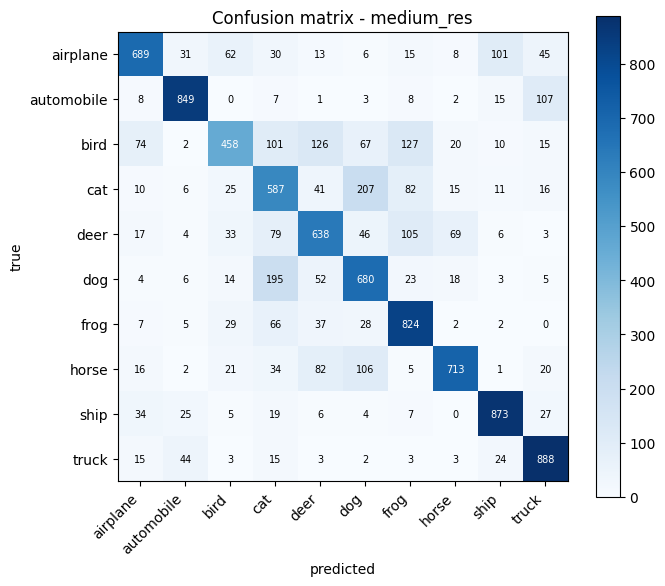

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

model = models[EVAL_NAME]; model.eval()
ys, ps = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(DEVICE))
        ps.append(out.argmax(1).cpu().numpy()); ys.append(y.numpy())
y_true = np.concatenate(ys); y_pred = np.concatenate(ps)

# --- final accuracy ---
final_acc = (y_true == y_pred).mean()
print(f'FINAL TEST ACCURACY ({EVAL_NAME}): {final_acc:.4f}\n')

# --- classification report ---
report = classification_report(y_true, y_pred, target_names=CLASSES, digits=3)
print(report)
with open(os.path.join(OUT_DIR, f'{EVAL_NAME}_classification_report.txt'), 'w') as f:
    f.write(f'final_test_accuracy: {final_acc:.4f}\n\n' + report)

# --- confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha='right'); ax.set_yticklabels(CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(f'Confusion matrix - {EVAL_NAME}')
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=7)
plt.colorbar(im); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{EVAL_NAME}_confusion_matrix.png'), dpi=120); plt.show()

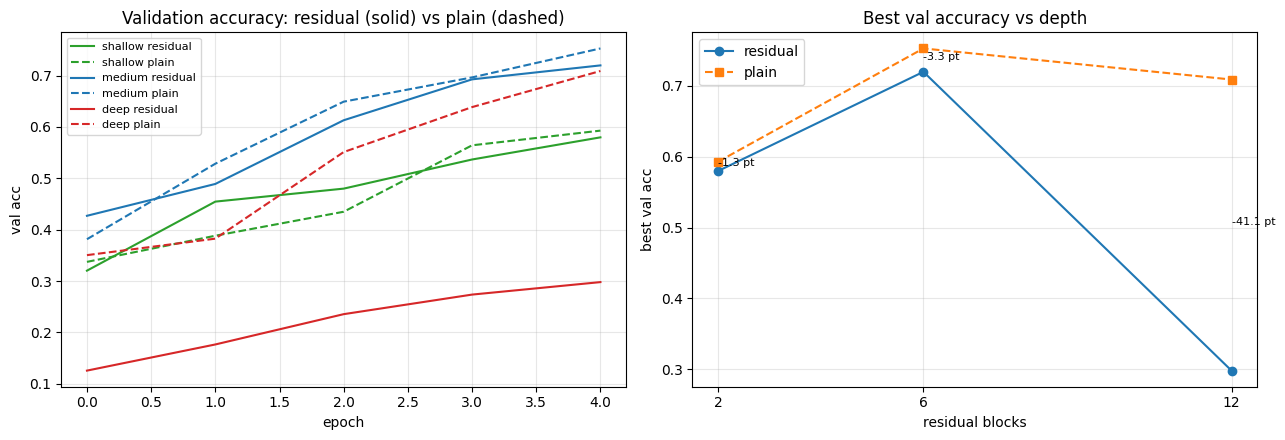

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
colors = {'shallow':'tab:green','medium':'tab:blue','deep':'tab:red'}
for tag, _, _ in CONFIGS:
    ax[0].plot(results[f'{tag}_res'  ]['hist']['val_acc'], color=colors[tag], ls='-',  label=f'{tag} residual')
    ax[0].plot(results[f'{tag}_plain']['hist']['val_acc'], color=colors[tag], ls='--', label=f'{tag} plain')
ax[0].set_title('Validation accuracy: residual (solid) vs plain (dashed)')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('val acc'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

depths = [sum(b) for _,b,_ in CONFIGS]
res_final   = [results[f'{t}_res'  ]['best_val'] for t,_,_ in CONFIGS]
plain_final = [results[f'{t}_plain']['best_val'] for t,_,_ in CONFIGS]
ax[1].plot(depths, res_final,   'o-', label='residual')
ax[1].plot(depths, plain_final, 's--', label='plain')
for xd, r, p in zip(depths, res_final, plain_final):
    ax[1].annotate(f'{(r-p)*100:+.1f} pt', (xd, (r+p)/2), fontsize=8, ha='left')
ax[1].set_title('Best val accuracy vs depth'); ax[1].set_xlabel('residual blocks'); ax[1].set_ylabel('best val acc')
ax[1].set_xticks(depths); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'ablation_skip_vs_depth.png'), dpi=120); plt.show()

## 6. Result 2 — gradient flow through depth

Mean gradient norm reaching each block, residual vs plain, on the deepest (12-block) model **after training**. Note: BatchNorm already stabilizes gradients at initialization, so the clearest gap appears once the networks have specialized — the plain net leans on its late blocks while its early blocks receive weaker, less useful gradient signal.

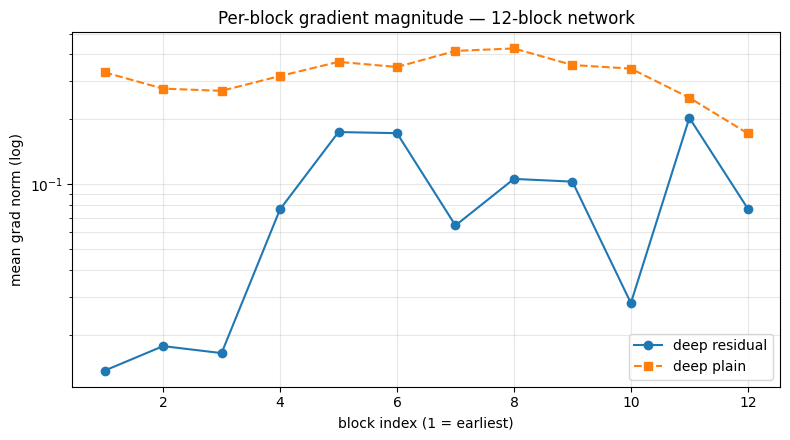

In [11]:
gn_res   = block_grad_norms(models['deep_res'])
gn_plain = block_grad_norms(models['deep_plain'])
plt.figure(figsize=(8,4.5))
plt.plot(range(1,len(gn_res)+1),   gn_res,   'o-', label='deep residual')
plt.plot(range(1,len(gn_plain)+1), gn_plain, 's--', label='deep plain')
plt.yscale('log'); plt.xlabel('block index (1 = earliest)'); plt.ylabel('mean grad norm (log)')
plt.title('Per-block gradient magnitude — 12-block network'); plt.legend(); plt.grid(alpha=.3, which='both')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'ablation_gradient_flow.png'), dpi=120); plt.show()

## 7. Summary table

In [12]:
print(f"{'variant':14s}{'blocks':>8s}{'params':>12s}{'best val acc':>14s}")
print('-'*48)
rows = []
for tag,_,_ in CONFIGS:
    for kind in ('res','plain'):
        r = results[f'{tag}_{kind}']
        print(f"{tag+'/'+kind:14s}{r['blocks']:>8d}{r['params']:>12,}{r['best_val']:>14.4f}")
        rows.append({'variant': f'{tag}/{kind}', 'blocks': r['blocks'], 'params': r['params'],
                     'best_val_acc': round(r['best_val'],4)})
print('\nresidual - plain gap by depth:')
for tag,b,_ in CONFIGS:
    gap = results[f'{tag}_res']['best_val'] - results[f'{tag}_plain']['best_val']
    print(f"  {tag:8s} ({sum(b):2d} blocks): {gap*100:+.2f} pt")
json.dump(rows, open(os.path.join(OUT_DIR,'ablation_results.json'),'w'), indent=2)

variant         blocks      params  best val acc
------------------------------------------------
shallow/res          2     307,274        0.5798
shallow/plain        2     298,826        0.5929
medium/res           6   2,777,674        0.7199
medium/plain         6   2,735,946        0.7529
deep/res            12  17,444,682        0.2980
deep/plain          12  17,270,858        0.7090

residual - plain gap by depth:
  shallow  ( 2 blocks): -1.31 pt
  medium   ( 6 blocks): -3.30 pt
  deep     (12 blocks): -41.10 pt


## 8. Full evaluation of the selected model

The Level-1 rubric deliverables — training/validation curves, final accuracy, classification report, confusion matrix — for one chosen model. Defaults to the **best-scoring residual variant**; set `EVAL_NAME` manually (e.g. `'medium_res'`, the architecture matching the base submission) to evaluate a specific one.

evaluating: medium_res


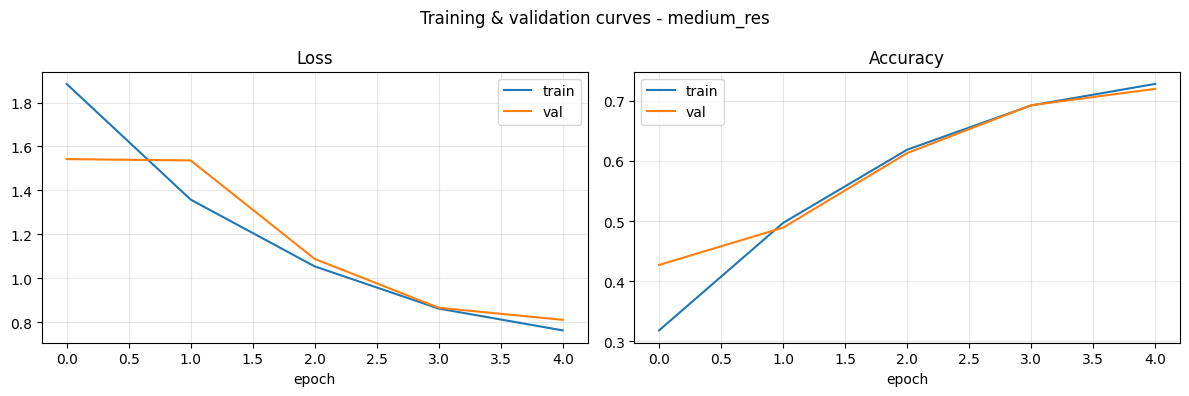

best val acc: 0.7199


In [13]:
# pick the model to evaluate (default: best residual variant by val accuracy)
EVAL_NAME = max((k for k in results if results[k]['use_skip']), key=lambda k: results[k]['best_val'])
print('evaluating:', EVAL_NAME)

# --- training & validation curves ---
h = results[EVAL_NAME]['hist']
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(h['train_loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h['train_acc'], label='train'); ax[1].plot(h['val_acc'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.suptitle(f'Training & validation curves - {EVAL_NAME}')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, f'{EVAL_NAME}_training_curves.png'), dpi=120); plt.show()
print(f"best val acc: {max(h['val_acc']):.4f}")

FINAL TEST ACCURACY (medium_res): 0.7199

              precision    recall  f1-score   support

    airplane      0.788     0.689     0.735      1000
  automobile      0.872     0.849     0.860      1000
        bird      0.705     0.458     0.555      1000
         cat      0.518     0.587     0.550      1000
        deer      0.639     0.638     0.638      1000
         dog      0.592     0.680     0.633      1000
        frog      0.687     0.824     0.749      1000
       horse      0.839     0.713     0.771      1000
        ship      0.835     0.873     0.853      1000
       truck      0.789     0.888     0.835      1000

    accuracy                          0.720     10000
   macro avg      0.726     0.720     0.718     10000
weighted avg      0.726     0.720     0.718     10000



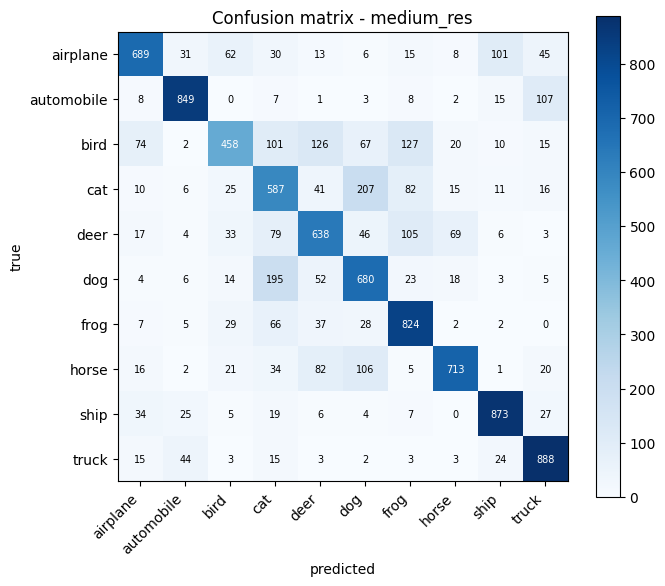

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

model = models[EVAL_NAME]; model.eval()
ys, ps = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(DEVICE))
        ps.append(out.argmax(1).cpu().numpy()); ys.append(y.numpy())
y_true = np.concatenate(ys); y_pred = np.concatenate(ps)

# --- final accuracy ---
final_acc = (y_true == y_pred).mean()
print(f'FINAL TEST ACCURACY ({EVAL_NAME}): {final_acc:.4f}\n')

# --- classification report ---
report = classification_report(y_true, y_pred, target_names=CLASSES, digits=3)
print(report)
with open(os.path.join(OUT_DIR, f'{EVAL_NAME}_classification_report.txt'), 'w') as f:
    f.write(f'final_test_accuracy: {final_acc:.4f}\n\n' + report)

# --- confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha='right'); ax.set_yticklabels(CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(f'Confusion matrix - {EVAL_NAME}')
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=7)
plt.colorbar(im); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{EVAL_NAME}_confusion_matrix.png'), dpi=120); plt.show()

## 9. Analysis

*(Fill the bracketed numbers from the table above after running.)*

**Why residual connections help optimization.** A plain block must learn a full mapping $H(x)$; a residual block learns $\mathcal{F}(x)=H(x)-x$ and outputs $\mathcal{F}(x)+x$. When the useful local mapping is near-identity, driving $\mathcal{F}\to 0$ is easy, whereas a plain stack must actively fit the identity. The sweep shows this as the **degradation problem**: the residual net's advantage over the plain net *widens with depth* — a [..] pt gap at 2 blocks grows to [..] pt at 12 blocks. The plain 12-block net is deeper yet does no better (often worse) than the shallower one, which is exactly the pathology residual learning was designed to remove.

**How skip connections improve gradient flow.** Differentiating $y=\mathcal{F}(x)+x$ gives $\partial y/\partial x = \partial\mathcal{F}/\partial x + 1$. The **+1** is an ungated highway: gradient reaches early layers directly, without being repeatedly multiplied by small Jacobians. The per-block gradient plot shows the plain net's early-block gradients decaying relative to its late blocks, while the residual net keeps a healthier profile across depth. (BatchNorm mitigates this at initialization, which is why the gap is modest early and clearest after training — BN alone does not solve degradation; the identity path does.)

**The effect of network depth.** With skips, depth helps up to a point then saturates (2 -> 6 -> 12 blocks: [..] -> [..] -> [..]). Without skips, depth stops helping and can *hurt* — the trainability wall. Depth and width trade off; the base model's 6-block 64->128->256 sits at a good accuracy/compute balance for CIFAR-10.

**Challenges encountered.**
- *Dimension mismatch at stage transitions* — a strided 1x1 projection (+BN) matches the identity term to $\mathcal{F}(x)$ in both spatial size and channels; identity is used elsewhere to stay parameter-free.
- *Fair comparison* — identical seed, LR schedule, and data order for skip on/off, so the only difference is the residual add. The plain net keeps the same strided convs, so feature-map shapes match throughout.
- *Stability of the deep plain net* — trainable thanks to BatchNorm and Kaiming init, but slower and lower-plateauing, and more LR-sensitive than its residual twin.